In [24]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
#from sklearn.model_selection import RandomizedSearchCV
#from scipy.stats import uniform, randint
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
dataset_path = "/home/nigus/EDU/Supervised/2_Ensemble/ES02"
print("Datasets found:", dataset_path)

Datasets found: /home/nigus/EDU/Supervised/2_Ensemble/ES02


In [26]:
# Read dataset
dataset = sio.loadmat(os.path.join(dataset_path, "dataset.mat"))
print("Keys in .mat file:", dataset.keys())

training_dataset = dataset["data_tr"]
training_labels = dataset["labels_tr"].flatten()

test_data = dataset["data_te"]
test_labels = dataset["labels_te"].flatten()

print("Training data shape:", training_dataset.shape)
print("Training labels shape:", training_labels.shape)
print("Test data shape:", test_data.shape)
print("Test labels shape:", test_labels.shape)

Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'data_te', 'data_tr', 'labels_te', 'labels_tr'])
Training data shape: (600, 2)
Training labels shape: (600,)
Test data shape: (600, 2)
Test labels shape: (600,)


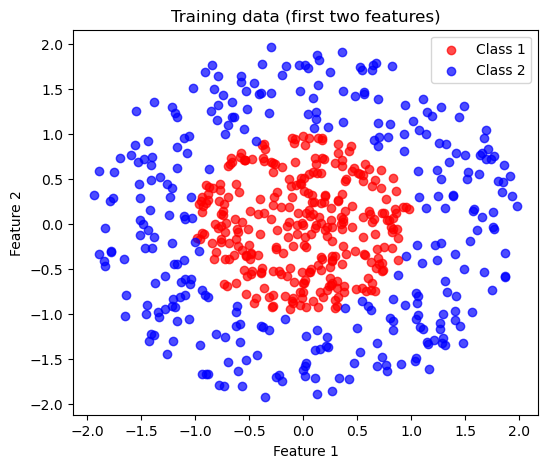

In [27]:
# Visualization of first 2 features
plt.figure(figsize=(6, 5))
plt.scatter(training_dataset[training_labels == 1, 0], training_dataset[training_labels == 1, 1], c="r", label="Class 1", alpha=0.7)
plt.scatter(training_dataset[training_labels == 2, 0], training_dataset[training_labels == 2, 1], c="b", label="Class 2", alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training data (first two features)")
plt.legend()
plt.show()

In [28]:
# Stratified split of the training dataset into  training dataset1 and validation dataset
training_dataset1, validation_dataset, training_labels1, validation_labels = train_test_split(
    training_dataset,
    training_labels,
    test_size=0.3,
    stratify=training_labels,
    random_state=42
)

print("Training_dataset1 shape:", training_dataset1.shape, training_labels1.shape)
print("Validation_dataset shape:", validation_dataset.shape, validation_labels.shape)


Training_dataset1 shape: (420, 2) (420,)
Validation_dataset shape: (180, 2) (180,)


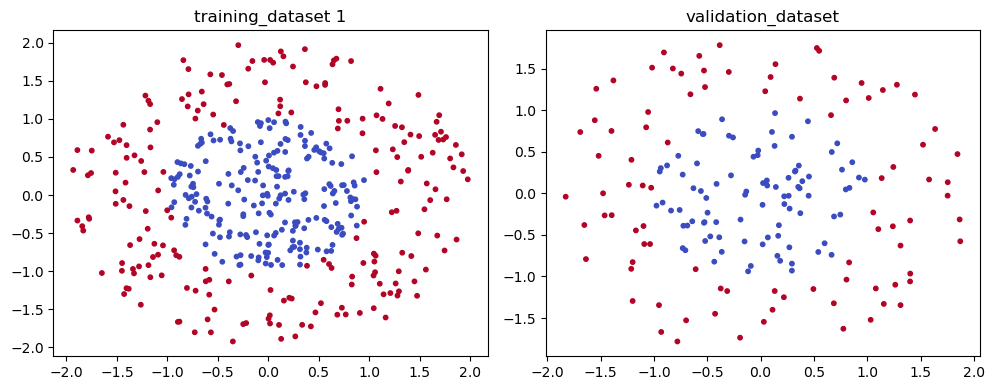

In [29]:
# Visualization of training dataset1 and validation dataset ... Scatter plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(training_dataset1[:,0], training_dataset1[:,1], c=training_labels1, cmap='coolwarm', s=10)
plt.title("training_dataset 1")

plt.subplot(1,2,2)
plt.scatter(validation_dataset[:,0], validation_dataset[:,1], c=validation_labels, cmap='coolwarm', s=10)
plt.title("validation_dataset")

plt.tight_layout()
plt.show()

In [30]:
# Train level 1 classifiers on Training  dataset1 using  Grid search
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# SVM Radial Basis Function
svm_rbf = {
    "C": [0.2, 1, 10],
    "gamma": ["scale", "auto", 0.1, 0.01]
}

grid_svm_rbf = GridSearchCV(
    SVC(kernel='rbf', probability=True),
    svm_rbf,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm_rbf.fit(training_dataset1, training_labels1)
best_svm_rbf = grid_svm_rbf.best_estimator_

# SVM Polynomial
svm_polynomial = {
    "C": [0.1, 1, 10],
    "degree": [2, 3, 4],
    "gamma": ['scale', 'auto', 0.1, 0.01]
}

grid_svm_poly = GridSearchCV(
    SVC(kernel="poly", probability=True),
    svm_polynomial,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm_poly.fit(training_dataset1, training_labels1)
best_svm_poly = grid_svm_poly.best_estimator_

# Decision Tree
decision_tree = {
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(),
    decision_tree,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_tree.fit(training_dataset1, training_labels1)
best_tree = grid_tree.best_estimator_

# Random Forest
random_forest = {
    "n_estimators": [50, 100, 200],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    random_forest,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(training_dataset1, training_labels1)
best_rf = grid_rf.best_estimator_

models = [
    ("SVM-Polynomial", best_svm_poly),
    ("SVM-RBF", best_svm_rbf),
    ("Decision Tree", best_tree),
    ("Random Forest", best_rf)
]

print("\nBest SVM-RBF:", grid_svm_rbf.best_params_)
print("Best SVM-Polynomial:", grid_svm_poly.best_params_)
print("Best Decision Tree:", grid_tree.best_params_)
print("Best Random Forest:", grid_rf.best_params_, "\n")


Best SVM-RBF: {'C': 10, 'gamma': 'scale'}
Best SVM-Polynomial: {'C': 10, 'degree': 2, 'gamma': 'scale'}
Best Decision Tree: {'max_depth': 5, 'min_samples_split': 5}
Best Random Forest: {'min_samples_split': 2, 'n_estimators': 100} 



In [12]:
# Predictions and Scores on validation dataset
# Predictions: discrete class labels from level-1 models
# Scores: probability of one class from level-1 models
# labels are [1, 2], column index 1  corresponds to class 2.
# I used probability of class 2 as the score feature.

# Number of models
N_models = len(models)

# number of samples
n_samples = validation_dataset.shape[0]

# Initialize arrays
predictions_f2 = np.zeros((n_samples, N_models))
scores_f2 = np.zeros((n_samples, N_models))

for i, (name, model) in enumerate(models):

    # Predictions (hard labels)
    preds = model.predict(validation_dataset)
    predictions_f2[:, i] = preds

    # Probabilities (soft scores)
    proba = model.predict_proba(validation_dataset)

    #  Automatically select correct class index
    class_index = np.where(model.classes_ == 2)[0][0]  # class "2"
    scores_f2[:, i] = proba[:, class_index]

# Print shapes
print("Predictions shape:", predictions_f2.shape)
print("Scores shape:", scores_f2.shape)

Predictions shape: (180, 4)
Scores shape: (180, 4)


In [13]:
# Ensuring labels are 1D
validation_labels = validation_labels.ravel()
# META (Predictions)
meta_clf_predictions = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
meta_clf_predictions.fit(predictions_f2, validation_labels)

#  META (Scores)
meta_clf_scores = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
meta_clf_scores.fit(scores_f2, validation_labels)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [14]:
# Evaluate level 1 classifiers on test set
# Ensuring labels are 1D
test_labels = np.ravel(test_labels)

rows = []

for name, model in models:
    y_pred = np.ravel(model.predict(test_data))

    report = classification_report(
        test_labels, y_pred, digits=4, output_dict=True
    )

    rows.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Avg Precision": report["macro avg"]["precision"],
        "Avg Recall": report["macro avg"]["recall"],
        "Avg F1 score": report["macro avg"]["f1-score"]
    })

# Create DataFrame
level1_df = pd.DataFrame(rows)

print("\nLEVEL-1 CLASSIFIERS SUMMARY\n")
print(level1_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"), "\n")


LEVEL-1 CLASSIFIERS SUMMARY

         Model  Accuracy  Avg Precision  Avg Recall  Avg F1 score
SVM-Polynomial    0.9917         0.9918      0.9917        0.9917
       SVM-RBF    0.9883         0.9886      0.9883        0.9883
 Decision Tree    0.9550         0.9551      0.9550        0.9550
 Random Forest    0.9617         0.9618      0.9617        0.9617 



In [15]:
# Number of models
N_models = len(models)
n_samples = test_data.shape[0]

# Initialize arrays
predictions_te = np.zeros((n_samples, N_models), dtype=int)
scores_te = np.zeros((n_samples, N_models))

for i, (name, model) in enumerate(models):

    # Predictions
    predictions_te[:, i] = model.predict(test_data)

    # Probabilities
    proba = model.predict_proba(test_data)
    # Automatically get correct class index
    positive_class = sorted(model.classes_)[-1]
    class_index = np.where(model.classes_ == positive_class)[0][0]
    scores_te[:, i] = proba[:, class_index]
    
# Debug prints
print("Test Predictions shape:", predictions_te.shape)
print("Test Scores shape:", scores_te.shape)

Test Predictions shape: (600, 4)
Test Scores shape: (600, 4)


In [16]:
# EVALUATE META-CLASSIFIER ON TEST SET
# Ensuring labels are 1D
test_labels = np.ravel(test_labels)

# Meta-classifier predictions on test set
meta_pred_test = np.ravel(meta_clf_predictions.predict(predictions_te))
meta_score_test = np.ravel(meta_clf_scores.predict(scores_te))

# Accuracies
acc_meta_predictions = accuracy_score(test_labels, meta_pred_test)
acc_meta_scores = accuracy_score(test_labels, meta_score_test)

report_pred = classification_report(
    test_labels, meta_pred_test, digits=4, output_dict=True
)
report_score = classification_report(
    test_labels, meta_score_test, digits=4, output_dict=True
)

metrics_df = pd.DataFrame({
    "Model": ["Split (Predictions)", "Split (Scores)"],
    "Accuracy": [
        report_pred["accuracy"],
        report_score["accuracy"]
    ],
    "Macro Precision": [
        report_pred["macro avg"]["precision"],
        report_score["macro avg"]["precision"]
    ],
    "Macro Recall": [
        report_pred["macro avg"]["recall"],
        report_score["macro avg"]["recall"]
    ],
    "Macro F1": [
        report_pred["macro avg"]["f1-score"],
        report_score["macro avg"]["f1-score"]
    ]
})

print("\n Meta classifiers evaluation metrices summary on Splitted dataset")
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"), "\n")


 Meta classifiers evaluation metrices summary on Splitted dataset
              Model  Accuracy  Macro Precision  Macro Recall  Macro F1
Split (Predictions)    0.9917           0.9918        0.9917    0.9917
     Split (Scores)    0.9967           0.9967        0.9967    0.9967 



In [17]:
# NO SPLIT OF TRAINING SET
# Train level-1 models on the FULL training set,
# then generate outputs on the SAME training set,
# then train the meta-classifier on those outputs.
# This usually gives optimistic performance because the meta-classifier

# Ensuring labels are 1D
training_labels = training_labels.ravel()

# Full training of models (with no dataset split)
models_full = []

# Clone the best models from the above and retrain on full dataset
best_svm_rbf.fit(training_dataset, training_labels)
models_full.append(("SVM-RBF", best_svm_rbf))

best_svm_poly.fit(training_dataset, training_labels)
models_full.append(("SVM-Poly", best_svm_poly))

best_tree.fit(training_dataset, training_labels)
models_full.append(("Decision Tree", best_tree))

best_rf.fit(training_dataset, training_labels)
models_full.append(("Random Forest", best_rf))


In [18]:
# Ensuring labels are 1D
training_labels = np.ravel(training_labels)

# Number of samples and models
n_samples = training_dataset.shape[0]
N_models = len(models_full)

# Initialize meta-feature arrays
predictions_train_full = np.zeros((n_samples, N_models), dtype=int)
scores_train_full = np.zeros((n_samples, N_models))

for i, (name, model) in enumerate(models_full):
    predictions_train_full[:, i] = model.predict(training_dataset)

    proba = model.predict_proba(training_dataset)
    positive_class = sorted(model.classes_)[-1]
    class_index = np.where(model.classes_ == positive_class)[0][0]
    scores_train_full[:, i] = proba[:, class_index]

# Train with no-split meta-classifiers
meta_no_split_predictions = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)
meta_no_split_predictions.fit(predictions_train_full, training_labels)

meta_no_split_scores = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)
meta_no_split_scores.fit(scores_train_full, training_labels)

# checks
print("\npredictions_training_full shape:", predictions_train_full.shape)
print("scores_training_full shape:", scores_train_full.shape, "\n")


predictions_training_full shape: (600, 4)
scores_training_full shape: (600, 4) 



In [19]:
# Number of models and test samples
N_models = len(models_full)
n_test = test_data.shape[0]

# Build test meta-features from full-trained level-1 models
predictions_te_full = np.zeros((n_test, N_models), dtype=int)
scores_te_full = np.zeros((n_test, N_models))

for i, (name, model) in enumerate(models_full):
    predictions_te_full[:, i] = model.predict(test_data)

    proba = model.predict_proba(test_data)
    positive_class = sorted(model.classes_)[-1]
    class_index = np.where(model.classes_ == positive_class)[0][0]
    scores_te_full[:, i] = proba[:, class_index]

# Meta predictions
meta_no_split_pred_test = np.ravel(
    meta_no_split_predictions.predict(predictions_te_full)
)
meta_no_split_score_test = np.ravel(
    meta_no_split_scores.predict(scores_te_full)
)

# Accuracy
acc_meta_no_split_predictions = accuracy_score(test_labels, meta_no_split_pred_test)
acc_meta_no_split_scores = accuracy_score(test_labels, meta_no_split_score_test)

report_pred = classification_report(
    test_labels, meta_no_split_pred_test, digits=4, output_dict=True
)
report_score = classification_report(
    test_labels, meta_no_split_score_test, digits=4, output_dict=True
)

metrics_df1 = pd.DataFrame({
    "Model": ["No-split (Predictions)", "No-split (Scores)"],
    "Accuracy": [
        report_pred["accuracy"],
        report_score["accuracy"]
    ],
    "Avg Precision": [
        report_pred["macro avg"]["precision"],
        report_score["macro avg"]["precision"]
    ],
    "Avg Recall": [
        report_pred["macro avg"]["recall"],
        report_score["macro avg"]["recall"]
    ],
    "Avg F1 score": [
        report_pred["macro avg"]["f1-score"],
        report_score["macro avg"]["f1-score"]
    ]
})

print("\nMeta classifiers evaluation metrices summary without Spliting the dataset")
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"), "\n")


Meta classifiers evaluation metrices summary without Spliting the dataset
              Model  Accuracy  Macro Precision  Macro Recall  Macro F1
Split (Predictions)    0.9917           0.9918        0.9917    0.9917
     Split (Scores)    0.9967           0.9967        0.9967    0.9967 



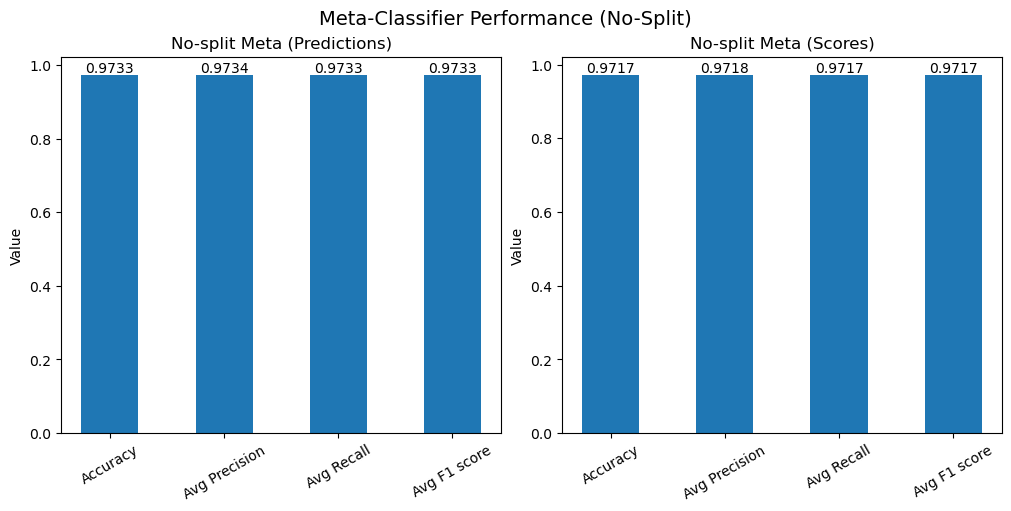

In [20]:
# Metrics
metrics = ["Accuracy", "Avg Precision", "Avg Recall", "Avg F1 score"]

# Values
pred_values = [
    metrics_df1.loc[0, "Accuracy"],
    metrics_df1.loc[0, "Avg Precision"],
    metrics_df1.loc[0, "Avg Recall"],
    metrics_df1.loc[0, "Avg F1 score"]
]

score_values = [
    metrics_df1.loc[1, "Accuracy"],
    metrics_df1.loc[1, "Avg Precision"],
    metrics_df1.loc[1, "Avg Recall"],
    metrics_df1.loc[1, "Avg F1 score"]
]

# spacing
x = np.arange(len(metrics)) * 0.8 
bar_width = 0.4                 

fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

# Predictions
axes[0].bar(x, pred_values, width=bar_width)
axes[0].set_title("No-split Meta (Predictions)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=30)
axes[0].set_ylabel("Value")

for i, v in enumerate(pred_values):
    axes[0].text(x[i], v, f"{v:.4f}", ha='center', va='bottom')

# Scores
axes[1].bar(x, score_values, width=bar_width)
axes[1].set_title("No-split Meta (Scores)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=30)
axes[1].set_ylabel("Value")

for i, v in enumerate(score_values):
    axes[1].text(x[i], v, f"{v:.4f}", ha='center', va='bottom')

plt.suptitle("Meta-Classifier Performance (No-Split)", fontsize=14)
plt.show()